# Лабораторная работа №1
## Первичное исследование и оценка качества данных

**Студент:** Михеев Никита Валерьевич
**Группа:** 302
**Датасет:** Bank Marketing (UCI)

In [2]:
import pandas as pd

df = pd.read_csv("../data/bank-additional-full.csv", sep=";")
print("Строк:", df.shape[0])
print("Столбцов:", df.shape[1])
df.head()

Строк: 41188
Столбцов: 21


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 1. Постановка задачи

### 1.1. Описание данных
Датасет Bank Marketing собран португальским банком в рамках кампаний прямого маркетинга (телефонные звонки клиентам с предложением открыть срочный вклад). Всего 41 188 записей и 21 признак, описывающих клиента, его предыдущие контакты с банком и социально-экономические показатели. Признаки включают числовые (возраст, длительность звонка, ставка Euribor), категориальные (профессия, семейное положение, образование) и временные (месяц и день недели последнего контакта).

### 1.2. Условный заказчик
Условный заказчик — маркетинговый отдел банка. Цель — повысить эффективность телефонных кампаний и снизить затраты на обзвон, определив, какие клиенты с большей вероятностью откроют вклад.

### 1.3. Возможные задачи ИАД
1. **Сегментация клиентов** — разделение клиентов на группы по схожим характеристикам для персонализации предложений.
2. **Поиск аномалий** — выявление нетипичных клиентов или звонков, которые могут указывать на ошибки данных.
3. **Описательная аналитика** — поиск закономерностей между признаками клиента и результатом кампании.

## 2. Паспорт датасета

### 2.1. Размер датасета

In [3]:
n_rows, n_cols = df.shape
print(f"Строк:    {n_rows}")
print(f"Столбцов: {n_cols}")

Строк:    41188
Столбцов: 21


### 2.2. Список признаков, типы и предполагаемый смысл

In [4]:
feature_meaning = {
    "age":            "Возраст клиента",
    "job":            "Род занятий",
    "marital":        "Семейное положение",
    "education":      "Уровень образования",
    "default":        "Есть ли кредит по умолчанию",
    "housing":        "Есть ли жилищный кредит",
    "loan":           "Есть ли личный кредит",
    "contact":        "Тип контакта (cellular / telephone)",
    "month":          "Месяц последнего контакта",
    "day_of_week":    "День недели последнего контакта",
    "duration":       "Длительность последнего звонка (сек)",
    "campaign":       "Число контактов в текущей кампании",
    "pdays":          "Дней с прошлого контакта (999 = не контактировали)",
    "previous":       "Число контактов до этой кампании",
    "poutcome":       "Результат предыдущей кампании",
    "emp.var.rate":   "Уровень занятости (квартальный)",
    "cons.price.idx": "Индекс потребительских цен (месячный)",
    "cons.conf.idx":  "Индекс потребительской уверенности (месячный)",
    "euribor3m":      "Ставка Euribor 3м (дневная)",
    "nr.employed":    "Количество занятых (квартальный)",
    "y":              "Целевой признак: открыл вклад? (yes/no)",
}

passport = pd.DataFrame({
    "Признак": df.columns,
    "Тип (pandas)": [str(t) for t in df.dtypes],
    "Уникальных": [df[c].nunique(dropna=True) for c in df.columns],
    "Пропусков, %": [round(df[c].isna().mean() * 100, 2) for c in df.columns],
    "Пример": [df[c].dropna().iloc[0] for c in df.columns],
    "Смысл": [feature_meaning.get(c, "—") for c in df.columns],
})
passport

,Признак,Тип (pandas),Уникальных,"Пропусков, %",Пример,Смысл
0,age,int64,78,0.0,56,Возраст клиента
1,job,str,12,0.0,housemaid,Род занятий
2,marital,str,4,0.0,married,Семейное положение
3,education,str,8,0.0,basic.4y,Уровень образования
4,default,str,3,0.0,no,Есть ли кредит по умолчанию
5,housing,str,3,0.0,no,Есть ли жилищный кредит
6,loan,str,3,0.0,no,Есть ли личный кредит
7,contact,str,2,0.0,telephone,Тип контакта (cellular / telephone)
8,month,str,10,0.0,may,Месяц последнего контакта
9,day_of_week,str,5,0.0,mon,День недели последнего контакта


### 2.3. Приведение типов

In [5]:
cat_like = ["job", "marital", "education", "default", "housing", "loan",
            "contact", "month", "day_of_week", "poutcome", "y"]
for c in cat_like:
    df[c] = df[c].astype("category")

df.dtypes

age                  int64
job               category
marital           category
education         category
default           category
housing           category
loan              category
contact           category
month             category
day_of_week       category
duration             int64
campaign             int64
pdays                int64
previous             int64
poutcome          category
emp.var.rate       float64
cons.price.idx     float64
cons.conf.idx      float64
euribor3m          float64
nr.employed        float64
y                 category
dtype: object

### Что изменили и почему

| Признак | Было | Стало | Причина |
|---|---|---|---|
| job, marital, education, default, housing, loan | str | category | Правильно отражает природу, экономит память |
| contact, month, day_of_week, poutcome, y | str | category | Это категории, а не свободный текст |

## 3. Аудит качества данных

### 3.1. Пропуски (Missing Values)

In [6]:
missing = pd.DataFrame({
    "Признак": df.columns,
    "Пропущено, шт.": df.isna().sum().values,
    "Доля, %": (df.isna().mean() * 100).round(2).values,
}).sort_values("Доля, %", ascending=False).reset_index(drop=True)
missing

,Признак,"Пропущено, шт.","Доля, %"
0,age,0,0.0
1,job,0,0.0
2,marital,0,0.0
3,education,0,0.0
4,default,0,0.0
5,housing,0,0.0
6,loan,0,0.0
7,contact,0,0.0
8,month,0,0.0
9,day_of_week,0,0.0


Явных пропусков (NaN) в датасете нет. Однако в категориальных признаках используется закодированное значение `'unknown'`, которое фактически означает пропуск.

In [7]:
print("Закодированные пропуски ('unknown'):\n")
for col in df.select_dtypes(include=["category", "object", "string"]).columns:
    n_unknown = (df[col] == "unknown").sum()
    if n_unknown > 0:
        print(f"  {col}: {n_unknown} ({n_unknown/len(df)*100:.2f}%)")

Закодированные пропуски ('unknown'):

  job: 330 (0.80%)
  marital: 80 (0.19%)
  education: 1731 (4.20%)
  default: 8597 (20.87%)
  housing: 990 (2.40%)
  loan: 990 (2.40%)


In [8]:
import numpy as np

df_clean = df.replace("unknown", np.nan)

# Сколько теперь стало пропусков
df_clean.isna().sum().sort_values(ascending=False).head(10)

default        8597
education      1731
housing         990
loan            990
job             330
marital          80
age               0
contact           0
month             0
day_of_week       0
dtype: int64

### Вывод по пропускам
- Явных NaN в датасете нет.
- Обнаружены закодированные пропуски `'unknown'` в признаках: `job`, `marital`, `education`, `default`, `housing`, `loan`.
- Больше всего — в `default` (~21%). Это может исказить анализ.
- Пропуски в `education` и `job` — умеренные (~4% и ~0.8%), можно заполнить модой или оставить как отдельную категорию.

### 3.2. Дубликаты

In [9]:
n_dup = df.duplicated().sum()
print(f"Полных дубликатов: {n_dup} ({n_dup / len(df) * 100:.2f}%)")

key_cols = ["age", "job", "marital", "education", "contact", "month", "day_of_week"]
n_key_dup = df.duplicated(subset=key_cols).sum()
print(f"Дубликатов по ключевым полям: {n_key_dup}")

Полных дубликатов: 12 (0.03%)
Дубликатов по ключевым полям: 17825


### Вывод по дубликатам
- Полных дубликатов: 12 (~0.03%). Их стоит удалить.
- Уникального идентификатора клиента нет, поэтому проверка по ключевым полям не даёт однозначного результата.

### 3.3. Типические проблемы значений

#### Числовые признаки

In [10]:
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00
duration,41188.0,258.29,259.28,0.00,102.00,180.00,319.00,4918.00
campaign,41188.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
pdays,41188.0,962.48,186.91,0.00,999.00,999.00,999.00,999.00
previous,41188.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00
emp.var.rate,41188.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,41188.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,41188.0,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,41188.0,3.62,1.73,0.63,1.34,4.86,4.96,5.04
nr.employed,41188.0,5167.04,72.25,4963.60,5099.10,5191.00,5228.10,5228.10


#### Категориальные признаки

In [11]:
for col in df.select_dtypes(include=["category"]).columns:
    print(f"{col}: {df[col].nunique()} уникальных значений")

job: 12 уникальных значений
marital: 4 уникальных значений
education: 8 уникальных значений
default: 3 уникальных значений
housing: 3 уникальных значений
loan: 3 уникальных значений
contact: 2 уникальных значений
month: 10 уникальных значений
day_of_week: 5 уникальных значений
poutcome: 3 уникальных значений
y: 2 уникальных значений


### Вывод по типическим проблемам
- В числовых признаках нет отрицательных значений.
- `pdays = 999` встречается в ~96% строк — это специальный код, требующий отдельной обработки.
- Признак `duration` известен только после звонка, поэтому его нельзя использовать в прогнозных моделях.
- Категориальные признаки чистые, явных «грязных» категорий нет.

### 3.4. Выбросы (Outliers)

In [12]:
TARGET_COL = "duration"

Q1 = df[TARGET_COL].quantile(0.25)
Q3 = df[TARGET_COL].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

mask_outliers = (df[TARGET_COL] < lower) | (df[TARGET_COL] > upper)
print(f"Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
print(f"Границы: [{lower:.2f}, {upper:.2f}]")
print(f"Выбросов: {mask_outliers.sum()} ({mask_outliers.mean()*100:.2f}%)")

Q1 = 102.00, Q3 = 319.00, IQR = 217.00
Границы: [-223.50, 644.50]
Выбросов: 2963 (7.19%)


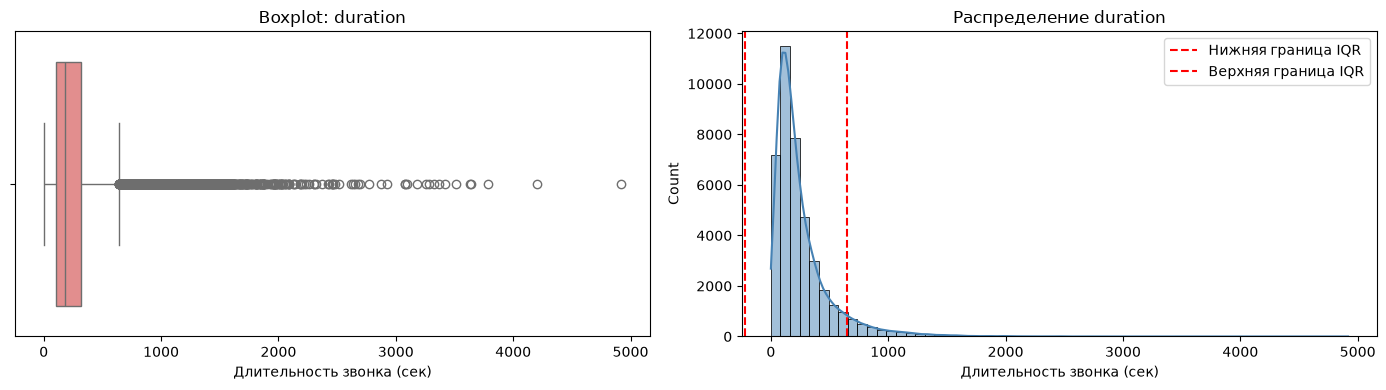

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x=df[TARGET_COL], ax=axes[0], color="lightcoral")
axes[0].set_title(f"Boxplot: {TARGET_COL}")
axes[0].set_xlabel("Длительность звонка (сек)")

sns.histplot(df[TARGET_COL], bins=60, kde=True, ax=axes[1], color="steelblue")
axes[1].axvline(lower, color="red", ls="--", label="Нижняя граница IQR")
axes[1].axvline(upper, color="red", ls="--", label="Верхняя граница IQR")
axes[1].set_title(f"Распределение {TARGET_COL}")
axes[1].set_xlabel("Длительность звонка (сек)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Вывод по выбросам
- Признак `duration` сильно скошен вправо, есть длинный хвост.
- Метод IQR находит около 7% выбросов — это очень длинные звонки (> 10 минут).
- Эти выбросы не ошибки, а реальные долгие разговоры. Удалять их не стоит, но при моделировании нужно учитывать скошенность.

## 4. Разведочный анализ (Mini-EDA)

### 4.1. Распределение возраста клиентов

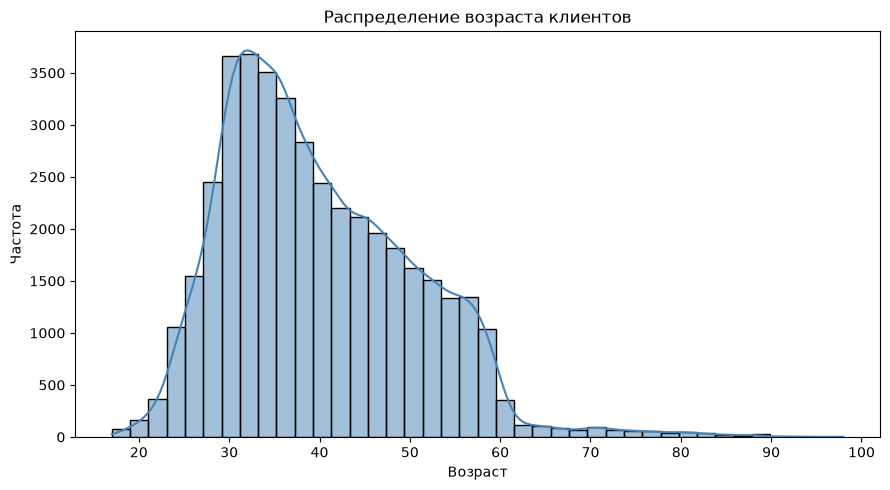

In [14]:
plt.figure(figsize=(9, 5))
sns.histplot(df["age"], bins=40, kde=True, color="steelblue")
plt.title("Распределение возраста клиентов")
plt.xlabel("Возраст")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()

**Комментарий.**  
Распределение возраста близко к нормальному, но слегка скошено вправо. Основная масса клиентов — 30–45 лет, есть длинный хвост до 90+. Гипотеза: банк ориентируется на клиентов среднего возраста, но у пожилых клиентов может быть выше отклик на вклады. Вопрос: отличаются ли пожилые клиенты по поведению?

### 4.2. Распределение по профессиям

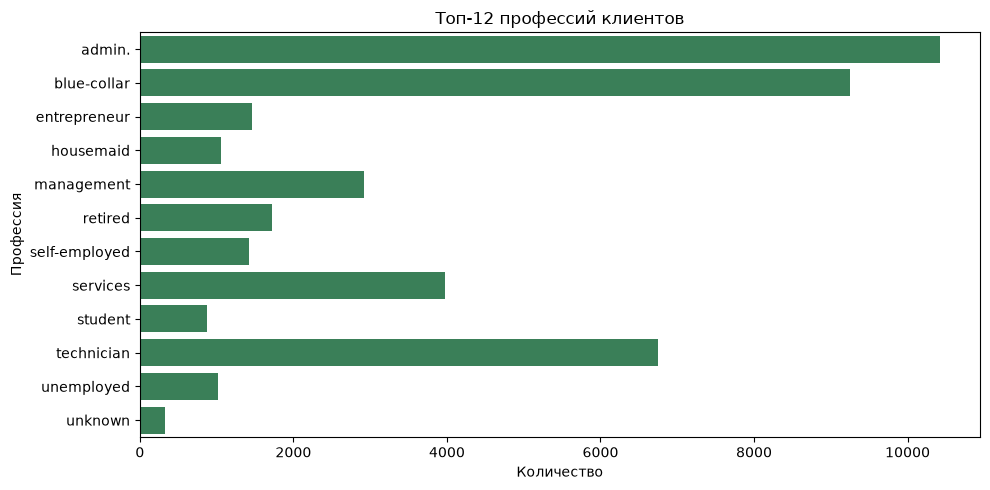

In [15]:
top_jobs = df["job"].value_counts().head(12)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_jobs.values, y=top_jobs.index, color="seagreen")
plt.title("Топ-12 профессий клиентов")
plt.xlabel("Количество")
plt.ylabel("Профессия")
plt.tight_layout()
plt.show()

**Комментарий.**  
Самые частые категории — `admin.`, `blue-collar`, `technician`. Это ядро клиентской базы банка. Гипотеза: эти группы заслуживают отдельного анализа. Вопрос: у какой профессии самый высокий отклик на кампанию?

### 4.3. Зависимость возраста от результата кампании

C:\Users\Mother Hacker\AppData\Local\Temp\ipykernel_11624\1067904224.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="y", y="age", palette="Set2")


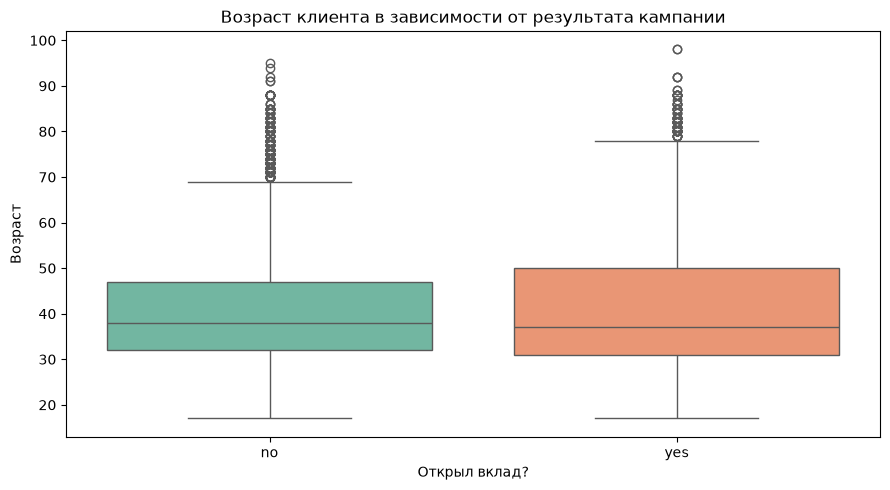

In [16]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="y", y="age", palette="Set2")
plt.title("Возраст клиента в зависимости от результата кампании")
plt.xlabel("Открыл вклад?")
plt.ylabel("Возраст")
plt.tight_layout()
plt.show()

**Комментарий.**  
Клиенты, открывшие вклад (`yes`), в среднем старше, чем те, кто отказался. Медиана возраста у группы `yes` заметно выше. Гипотеза: пожилые клиенты более склонны к срочным вкладам. Вопрос: сохранится ли этот эффект при контроле по профессии?

## 5. Выводы

В ходе первичного исследования датасета Bank Marketing (41 188 строк, 21 признак) были сделаны следующие выводы:

**Структура и качество данных:**
- Явных пропусков нет, но есть закодированные `'unknown'` в 6 категориальных признаках. Больше всего — в `default` (~21%).
- Обнаружено 12 полных дубликатов строк.
- `pdays = 999` — специальный код, встречается в ~96% записей.

**Подозрительные значения:**
- Признак `duration` известен только после звонка — его нельзя использовать в прогнозных моделях.
- Числовые признаки не содержат отрицательных значений.

**Выбросы:**
- В `duration` методом IQR найдено 2963 выброса (7.19%). Это реальные длинные звонки, не ошибки данных.
- Распределение сильно скошено вправо — стоит логарифмировать при моделировании.

**Целевая переменная:**
- `y` сильно несбалансирована: класс `no` доминирует (~89%), `yes` — ~11%.

**Задачи для следующих шагов:**
1. Очистка: удалить дубликаты, заменить `unknown` на NaN.
2. Обработать `pdays = 999` — заменить на NaN или отдельный флаг.
3. Использовать `class_weight` или oversampling для дисбаланса классов.
4. Логарифмировать `duration` и `campaign`.
5. Исключить `duration` из прогнозных моделей.